In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.graphics.gofplots import ProbPlot

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel
from sklearn.metrics import r2_score
from sklearn.model_selection import LeaveOneOut, cross_val_predict

import warnings
warnings.filterwarnings('ignore')

In [6]:
import matplotlib as mpl
import matplotlib.font_manager as fm

font_path = r"C:\Windows\Fonts\malgun.ttf"
font_prop = fm.FontProperties(fname=font_path)
mpl.rcParams['font.family'] = font_prop.get_name()
mpl.rcParams['axes.unicode_minus'] = False

In [7]:
df_raw = pd.read_excel('../datasets/swatch.xlsx')
orig_cols = df_raw.columns.tolist()
label_w  = orig_cols[1]
label_b  = orig_cols[2]
label_gd = orig_cols[3]
label_hd = orig_cols[4]

df = df_raw.rename(columns={
    orig_cols[1]: 'weight',
    orig_cols[2]: 'BET',
    orig_cols[3]: 'GD',
    orig_cols[4]: 'HD'
})

GD_base = 357
HD_base = 671
samples = df['Sample'].tolist()
n = len(df)

w = df['weight'].values
b = df['BET'].values
y_GD = df['GD'].values
y_HD = df['HD'].values

display(df)

,Sample,weight,BET,GD,HD
0,ACF25-01,105.20,1150,320,280
1,ACF25-02,99.30,1450,470,220
2,ACF25-03,119.70,1150,1150,550
3,ACF25-04,110.40,1300,850,850
4,ACF25-05,103.44,1016,470,580
5,ACF25-06,122.83,1080,20,140
6,ACF25-07,154.49,1139,380,10
7,ACF25-08,140.00,1300,20,5
8,ACF25-09,130.00,2197,50,5


# 1. 변수 변환을 통한 선형회귀 개선

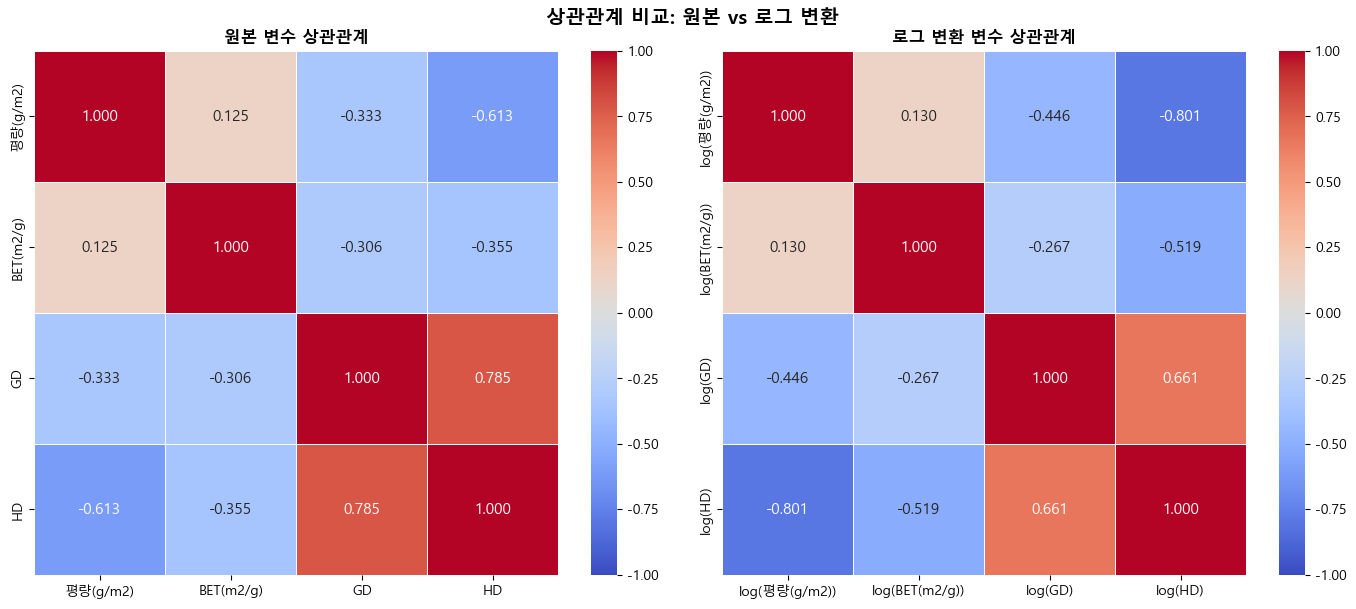

In [8]:
# 원본 vs 로그 변환 상관관계 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

data_orig = df[['weight', 'BET', 'GD', 'HD']].copy()
data_orig.columns = [label_w, label_b, 'GD', 'HD']

data_log = pd.DataFrame({
    f'log({label_w})': np.log(df['weight']),
    f'log({label_b})': np.log(df['BET']),
    'log(GD)': np.log(df['GD']),
    'log(HD)': np.log(df['HD']),
})

for ax, data, title in zip(axes,
                             [data_orig, data_log],
                             ['원본 변수 상관관계', '로그 변환 변수 상관관계']):
    corr = data.corr()
    sns.heatmap(corr, ax=ax, annot=True, fmt='.3f', cmap='coolwarm',
                vmin=-1, vmax=1, square=True, linewidths=0.5,
                annot_kws={'size': 11})
    ax.set_title(title, fontsize=12, fontweight='bold')

plt.suptitle('상관관계 비교: 원본 vs 로그 변환', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# 변환 조합별 OLS 성능 비교
loo = LeaveOneOut()

transform_specs = [
    ('원본',                          y_GD,          y_HD,          w,          b),
    ('log(y)',                         np.log(y_GD),  np.log(y_HD),  w,          b),
    ('log(y), log(BET)',               np.log(y_GD),  np.log(y_HD),  w,          np.log(b)),
    ('log(y), log(무게), log(BET)',    np.log(y_GD),  np.log(y_HD),  np.log(w),  np.log(b)),
    ('sqrt(y)',                        np.sqrt(y_GD), np.sqrt(y_HD), w,          b),
    ('sqrt(y), log(BET)',              np.sqrt(y_GD), np.sqrt(y_HD), w,          np.log(b)),
    ('sqrt(y), log(무게), log(BET)',   np.sqrt(y_GD), np.sqrt(y_HD), np.log(w),  np.log(b)),
]

rows_GD, rows_HD = [], []
models_by_name = {}

for name, yt_GD, yt_HD, x1_t, x2_t in transform_specs:
    X = sm.add_constant(np.column_stack([x1_t, x2_t]))
    m_GD = sm.OLS(yt_GD, X).fit()
    m_HD = sm.OLS(yt_HD, X).fit()
    models_by_name[name] = (m_GD, m_HD, yt_GD, yt_HD, x1_t, x2_t)

    rows_GD.append({
        '변환': name,
        'R²': round(m_GD.rsquared, 3),
        'adj-R²': round(m_GD.rsquared_adj, 3),
        'F p-값': round(m_GD.f_pvalue, 4),
        'p(무게)': round(m_GD.pvalues[1], 4),
        'p(BET)': round(m_GD.pvalues[2], 4),
    })
    rows_HD.append({
        '변환': name,
        'R²': round(m_HD.rsquared, 3),
        'adj-R²': round(m_HD.rsquared_adj, 3),
        'F p-값': round(m_HD.f_pvalue, 4),
        'p(무게)': round(m_HD.pvalues[1], 4),
        'p(BET)': round(m_HD.pvalues[2], 4),
    })

df_comp_GD = pd.DataFrame(rows_GD).sort_values('adj-R²', ascending=False).reset_index(drop=True)
df_comp_HD = pd.DataFrame(rows_HD).sort_values('adj-R²', ascending=False).reset_index(drop=True)

print('=== GD 보호농도 — 변환별 OLS 비교 (adj-R² 내림차순) ===')
display(df_comp_GD.style
        .background_gradient(subset=['adj-R²', 'R²'], cmap='YlGn')
        .highlight_min(subset=['F p-값', 'p(무게)', 'p(BET)'], color='#90EE90'))

print('\n=== HD 보호농도 — 변환별 OLS 비교 (adj-R² 내림차순) ===')
display(df_comp_HD.style
        .background_gradient(subset=['adj-R²', 'R²'], cmap='YlGn')
        .highlight_min(subset=['F p-값', 'p(무게)', 'p(BET)'], color='#90EE90'))

=== GD 보호농도 — 변환별 OLS 비교 (adj-R² 내림차순) ===


,변환,R²,adj-R²,F p-값,p(무게),p(BET)
0,"log(y), log(무게), log(BET)",0.243000,-0.009000,0.433800,0.287400,0.575400
1,sqrt(y),0.234000,-0.021000,0.449500,0.357600,0.462500
2,log(y),0.233000,-0.023000,0.451600,0.318800,0.535600
3,"sqrt(y), log(무게), log(BET)",0.229000,-0.028000,0.457900,0.340800,0.508300
4,"log(y), log(BET)",0.226000,-0.032000,0.464300,0.315800,0.564000
5,"sqrt(y), log(BET)",0.222000,-0.037000,0.470100,0.354000,0.498900
6,원본,0.182000,-0.091000,0.547800,0.452000,0.498000



=== HD 보호농도 — 변환별 OLS 비교 (adj-R² 내림차순) ===


,변환,R²,adj-R²,F p-값,p(무게),p(BET)
0,"log(y), log(BET)",0.831000,0.775000,0.004800,0.004300,0.043200
1,log(y),0.830000,0.774000,0.004900,0.004400,0.043700
2,"log(y), log(무게), log(BET)",0.816000,0.755000,0.006200,0.005500,0.054000
3,sqrt(y),0.671000,0.562000,0.035500,0.025800,0.181900
4,"sqrt(y), log(BET)",0.671000,0.562000,0.035600,0.025200,0.182600
5,"sqrt(y), log(무게), log(BET)",0.653000,0.537000,0.041800,0.030000,0.202900
6,원본,0.454000,0.272000,0.162700,0.106400,0.388100


In [10]:
# 최적 변환 상세 회귀 결과
best_name_GD = df_comp_GD.iloc[0]['변환']
best_name_HD = df_comp_HD.iloc[0]['변환']

best_m_GD, _, best_yt_GD, _, _, _ = models_by_name[best_name_GD]
_, best_m_HD, _, best_yt_HD, _, _ = models_by_name[best_name_HD]

print(f'[GD] 최적 변환: {best_name_GD}')
print(best_m_GD.summary())
print(f'\n[HD] 최적 변환: {best_name_HD}')
print(best_m_HD.summary())

[GD] 최적 변환: log(y), log(무게), log(BET)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.243
Model:                            OLS   Adj. R-squared:                 -0.009
Method:                 Least Squares   F-statistic:                    0.9630
Date:                Sat, 25 Apr 2026   Prob (F-statistic):              0.434
Time:                        18:52:19   Log-Likelihood:                -15.059
No. Observations:                   9   AIC:                             36.12
Df Residuals:                       6   BIC:                             36.71
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         

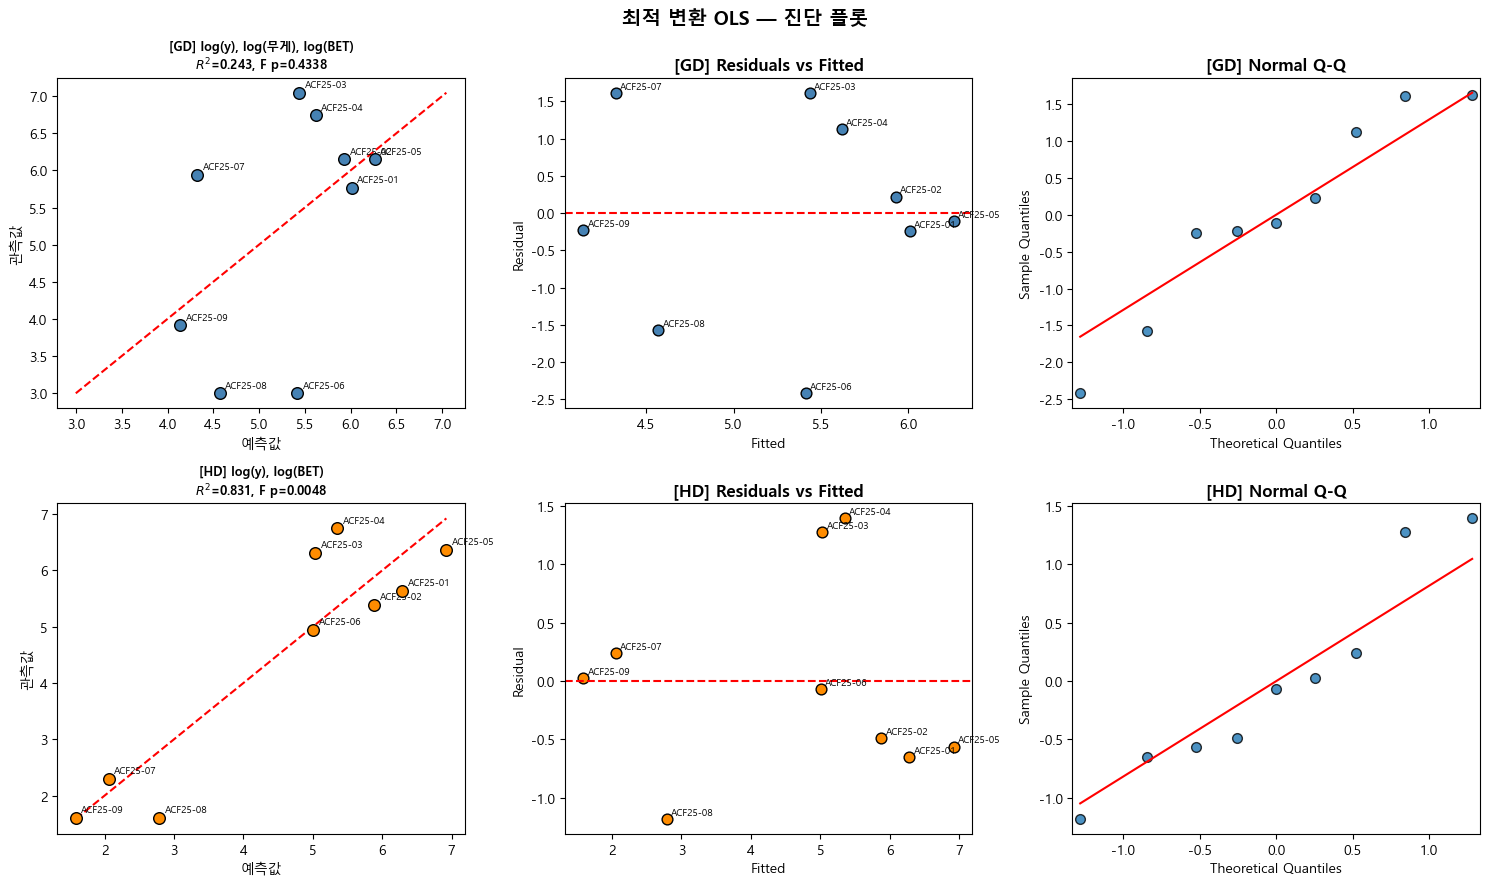

In [13]:
# 최적 변환 — Pred vs Observed + 잔차 진단
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for row, (target, best_name, best_m, yt, y_raw, color) in enumerate([
    ('GD', best_name_GD, best_m_GD, best_yt_GD, y_GD, 'steelblue'),
    ('HD', best_name_HD, best_m_HD, best_yt_HD, y_HD, 'darkorange'),
]):
    pred_t = best_m.fittedvalues
    resid  = best_m.resid

    # Pred vs Observed
    ax = axes[row][0]
    ax.scatter(pred_t, yt, color=color, edgecolors='black', s=70, zorder=5)
    mn, mx = min(float(yt.min()), float(pred_t.min())), max(float(yt.max()), float(pred_t.max()))
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
    for i, s in enumerate(samples):
        ax.annotate(s, (pred_t[i], yt[i]), fontsize=7,
                    xytext=(4, 4), textcoords='offset points')
    ax.set_xlabel('예측값')
    ax.set_ylabel('관측값')
    ax.set_title(f'[{target}] {best_name}\n$R^2$={best_m.rsquared:.3f}, F p={best_m.f_pvalue:.4f}',
                 fontsize=9, fontweight='bold')

    # Residuals vs Fitted
    ax = axes[row][1]
    ax.scatter(pred_t, resid, color=color, edgecolors='black', s=60)
    ax.axhline(0, color='red', linestyle='--')
    for i, s in enumerate(samples):
        ax.annotate(s, (pred_t[i], resid[i]), fontsize=7,
                    xytext=(3, 3), textcoords='offset points')
    ax.set_xlabel('Fitted')
    ax.set_ylabel('Residual')
    ax.set_title(f'[{target}] Residuals vs Fitted', fontweight='bold')

    # Normal Q-Q
    ax = axes[row][2]
    pp = ProbPlot(resid)
    pp.qqplot(line='s', ax=ax, alpha=0.8)
    for line in ax.get_lines():
        if line.get_linestyle() == 'None':
            line.set_color(color)
            line.set_markersize(7)
            line.set_markeredgecolor('black')
    ax.set_title(f'[{target}] Normal Q-Q', fontweight='bold')

plt.suptitle('최적 변환 OLS — 진단 플롯', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. 다항식 항 (2차항 + 상호작용항) + Ridge 회귀

In [15]:
# 다항 특성 생성
X_orig = df[['weight', 'BET']].values
poly   = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X_orig)
feat_names = poly.get_feature_names_out(['무게', 'BET'])

scaler_poly = StandardScaler()
X_scaled    = scaler_poly.fit_transform(X_poly)

df_feat = pd.DataFrame(X_poly, columns=feat_names, index=samples)
print('다항 특성 (원본 스케일):')
display(df_feat.round(2))
print(f'\n총 특성: {feat_names.tolist()}')

다항 특성 (원본 스케일):


,무게,BET,무게^2,무게 BET,BET^2
ACF25-01,105.20,1150.0,11067.04,120980.00,1322500.0
ACF25-02,99.30,1450.0,9860.49,143985.00,2102500.0
ACF25-03,119.70,1150.0,14328.09,137655.00,1322500.0
ACF25-04,110.40,1300.0,12188.16,143520.00,1690000.0
ACF25-05,103.44,1016.0,10699.83,105095.04,1032256.0
ACF25-06,122.83,1080.0,15087.21,132656.40,1166400.0
ACF25-07,154.49,1139.0,23867.16,175964.11,1297321.0
ACF25-08,140.00,1300.0,19600.00,182000.00,1690000.0
ACF25-09,130.00,2197.0,16900.00,285610.00,4826809.0



총 특성: ['무게', 'BET', '무게^2', '무게 BET', 'BET^2']


In [16]:
# Ridge 회귀 — LOOCV로 alpha 선택
alphas = np.logspace(-3, 5, 200)
ridge_results = {}

for target, y in [('GD', y_GD), ('HD', y_HD)]:
    ridge_cv = RidgeCV(alphas=alphas, cv=loo, scoring='r2')
    ridge_cv.fit(X_scaled, y)
    best_alpha = ridge_cv.alpha_

    ridge_best = Ridge(alpha=best_alpha)
    loo_preds  = cross_val_predict(ridge_best, X_scaled, y, cv=loo)
    loo_r2     = r2_score(y, loo_preds)
    loo_rmse   = np.sqrt(np.mean((y - loo_preds) ** 2))

    ridge_best.fit(X_scaled, y)
    in_preds = ridge_best.predict(X_scaled)
    in_r2    = r2_score(y, in_preds)

    ridge_results[target] = {
        'model': ridge_best, 'alpha': best_alpha,
        'in_r2': in_r2, 'loo_r2': loo_r2, 'loo_rmse': loo_rmse,
        'loo_preds': loo_preds, 'in_preds': in_preds, 'coefs': ridge_best.coef_,
    }
    print(f'[{target}] 최적 alpha={best_alpha:.4f} | 학습 R²={in_r2:.3f} | LOO R²={loo_r2:.3f} | LOO RMSE={loo_rmse:.1f}')

[GD] 최적 alpha=0.0010 | 학습 R²=0.242 | LOO R²=-20.070 | LOO RMSE=1669.8
[HD] 최적 alpha=0.0010 | 학습 R²=0.501 | LOO R²=-12.841 | LOO RMSE=1062.1


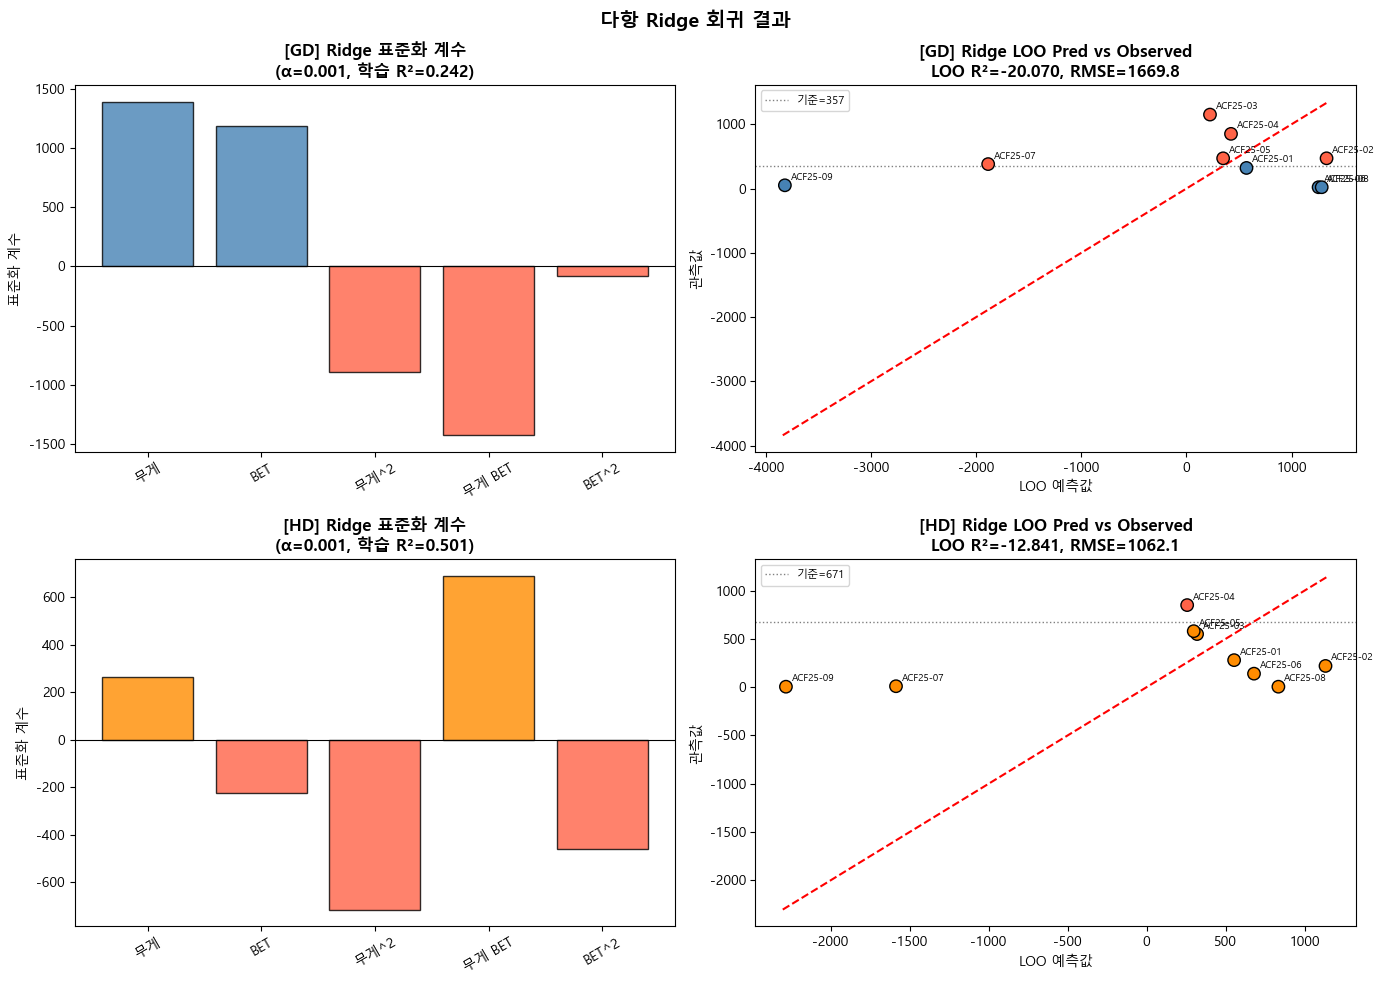

In [17]:
# Ridge 계수 + LOO Pred vs Observed
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (target, y, base, color) in enumerate([
    ('GD', y_GD, GD_base, 'steelblue'),
    ('HD', y_HD, HD_base, 'darkorange'),
]):
    r = ridge_results[target]

    # 계수 바차트
    ax = axes[row][0]
    bar_colors = ['tomato' if c < 0 else color for c in r['coefs']]
    ax.bar(feat_names, r['coefs'], color=bar_colors, edgecolor='black', alpha=0.8)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'[{target}] Ridge 표준화 계수\n(α={r["alpha"]:.3f}, 학습 R²={r["in_r2"]:.3f})',
                 fontweight='bold')
    ax.set_ylabel('표준화 계수')
    ax.tick_params(axis='x', rotation=30)

    # LOO Pred vs Observed
    ax = axes[row][1]
    preds = r['loo_preds']
    pt_colors = [color if v <= base else 'tomato' for v in y]
    ax.scatter(preds, y, c=pt_colors, edgecolors='black', s=80, zorder=5)
    mn = min(y.min(), preds.min()) - 20
    mx = max(y.max(), preds.max()) + 20
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
    ax.axhline(base, color='gray', linestyle=':', linewidth=1, label=f'기준={base}')
    for i, s in enumerate(samples):
        ax.annotate(s, (preds[i], y[i]), fontsize=7, xytext=(4, 4), textcoords='offset points')
    ax.set_xlabel('LOO 예측값')
    ax.set_ylabel('관측값')
    ax.set_title(f'[{target}] Ridge LOO Pred vs Observed\nLOO R²={r["loo_r2"]:.3f}, RMSE={r["loo_rmse"]:.1f}',
                 fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('다항 Ridge 회귀 결과', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

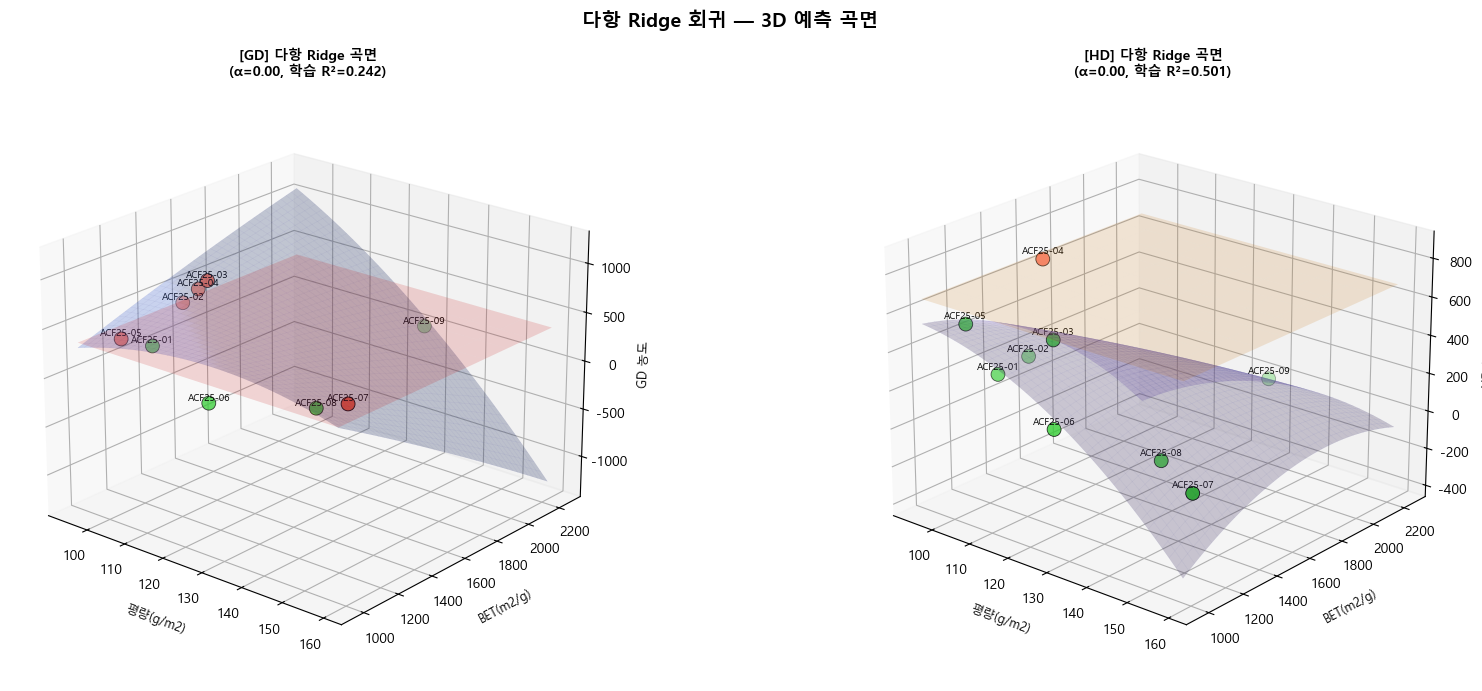

In [18]:
# Ridge 3D 예측 곡면
x1_arr = df['weight'].values
x2_arr = df['BET'].values

x1_grid = np.linspace(x1_arr.min() - 5,  x1_arr.max() + 5,  40)
x2_grid = np.linspace(x2_arr.min() - 50, x2_arr.max() + 50, 40)
X1g, X2g = np.meshgrid(x1_grid, x2_grid)
grid_flat = np.column_stack([X1g.ravel(), X2g.ravel()])

X_grid_poly   = poly.transform(grid_flat)
X_grid_scaled = scaler_poly.transform(X_grid_poly)

fig, axes_3d = plt.subplots(1, 2, figsize=(18, 7), subplot_kw={'projection': '3d'})

for ax, (target, y, base, surf_color, lim_color) in zip(axes_3d, [
    ('GD', y_GD, GD_base, 'royalblue',    'red'),
    ('HD', y_HD, HD_base, 'mediumpurple', 'darkorange'),
]):
    Zg = ridge_results[target]['model'].predict(X_grid_scaled).reshape(X1g.shape)
    pt_colors = ['limegreen' if v <= base else 'tomato' for v in y]

    ax.plot_surface(X1g, X2g, Zg, alpha=0.25, color=surf_color, edgecolor='none')
    ax.plot_wireframe(X1g, X2g, Zg, alpha=0.08, color='navy', linewidth=0.3)

    xx, yy = np.meshgrid(
        np.linspace(x1_arr.min()-5, x1_arr.max()+5, 10),
        np.linspace(x2_arr.min()-50, x2_arr.max()+50, 10))
    ax.plot_surface(xx, yy, np.full_like(xx, base), alpha=0.15, color=lim_color)

    ax.scatter(x1_arr, x2_arr, y, c=pt_colors, s=100,
               edgecolors='black', linewidths=0.6, depthshade=True, zorder=5)
    for xi, yi, zi, s in zip(x1_arr, x2_arr, y, samples):
        ax.text(xi, yi, zi + 25, s, fontsize=7, ha='center')

    ax.set_xlabel(label_w, fontsize=9, labelpad=8)
    ax.set_ylabel(label_b, fontsize=9, labelpad=8)
    ax.set_zlabel(f'{target} 농도', fontsize=9)
    ax.set_title(
        f'[{target}] 다항 Ridge 곡면\n(α={ridge_results[target]["alpha"]:.2f}, 학습 R²={ridge_results[target]["in_r2"]:.3f})',
        fontsize=10, fontweight='bold')
    ax.view_init(elev=22, azim=-50)

plt.suptitle('다항 Ridge 회귀 — 3D 예측 곡면', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. 가우시안 프로세스 회귀 (Gaussian Process Regression)

In [19]:
# GPR 적합
scaler_gpr = StandardScaler()
X_std = scaler_gpr.fit_transform(df[['weight', 'BET']].values)

kernel = (ConstantKernel(1.0, (1e-3, 1e3))
          * RBF([1.0, 1.0], (1e-2, 1e2))
          + WhiteKernel(0.5, (1e-4, 1e2)))

gpr_results = {}

for target, y in [('GD', y_GD), ('HD', y_HD)]:
    gpr = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=15,
                                   normalize_y=True)
    gpr.fit(X_std, y)

    in_pred, in_std = gpr.predict(X_std, return_std=True)
    in_r2 = r2_score(y, in_pred)

    # Leave-One-Out 예측
    loo_pred = np.zeros(n)
    loo_std  = np.zeros(n)
    for i in range(n):
        mask = np.ones(n, dtype=bool); mask[i] = False
        gpr_loo = GaussianProcessRegressor(
            kernel=gpr.kernel_, n_restarts_optimizer=0, normalize_y=True)
        gpr_loo.fit(X_std[mask], y[mask])
        p, s = gpr_loo.predict(X_std[i:i+1], return_std=True)
        loo_pred[i] = p[0]; loo_std[i] = s[0]

    loo_r2   = r2_score(y, loo_pred)
    loo_rmse = np.sqrt(np.mean((y - loo_pred) ** 2))

    gpr_results[target] = {
        'model': gpr, 'kernel_str': str(gpr.kernel_),
        'in_r2': in_r2, 'loo_r2': loo_r2, 'loo_rmse': loo_rmse,
        'loo_pred': loo_pred, 'loo_std': loo_std,
        'in_pred': in_pred, 'in_std': in_std,
    }

    print(f'[{target}] 학습 R²={in_r2:.3f} | LOO R²={loo_r2:.3f} | LOO RMSE={loo_rmse:.1f}')
    print(f'       최적 커널: {str(gpr.kernel_)}\n')

[GD] 학습 R²=0.976 | LOO R²=-0.266 | LOO RMSE=409.3
       최적 커널: 0.919**2 * RBF(length_scale=[0.01, 0.01]) + WhiteKernel(noise_level=0.155)

[HD] 학습 R²=0.680 | LOO R²=-0.199 | LOO RMSE=312.6
       최적 커널: 0.772**2 * RBF(length_scale=[0.532, 100]) + WhiteKernel(noise_level=0.5)



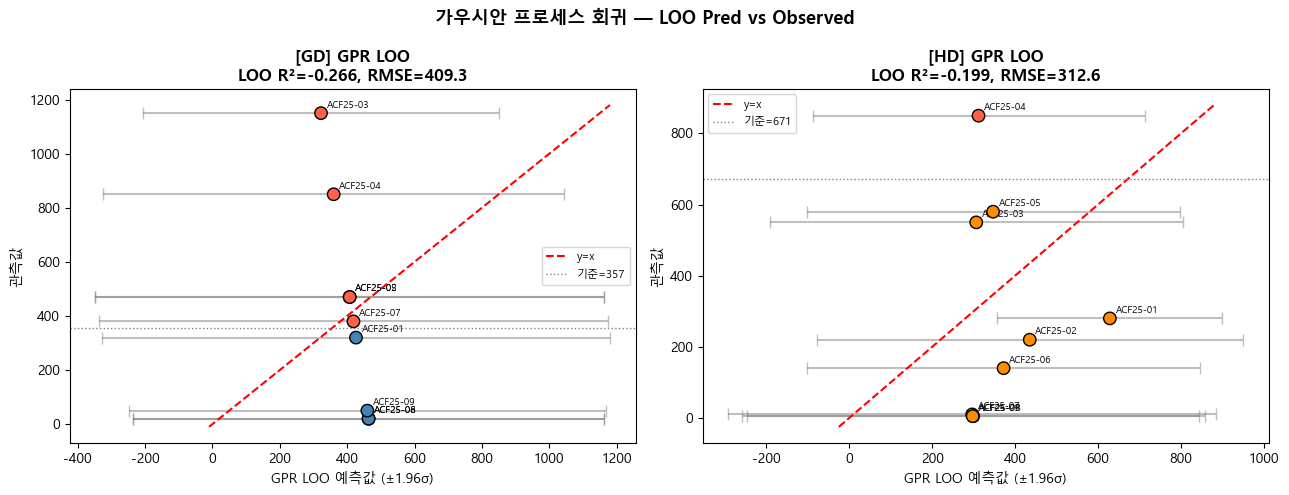

In [20]:
# GPR LOO Pred vs Observed + 불확실성
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (target, y, base, color) in zip(axes, [
    ('GD', y_GD, GD_base, 'steelblue'),
    ('HD', y_HD, HD_base, 'darkorange'),
]):
    r = gpr_results[target]
    preds, stds = r['loo_pred'], r['loo_std']

    pt_colors = [color if v <= base else 'tomato' for v in y]
    ax.errorbar(preds, y, xerr=1.96*stds, fmt='none',
                ecolor='gray', alpha=0.5, capsize=4)
    ax.scatter(preds, y, c=pt_colors, edgecolors='black', s=80, zorder=5)

    mn = min(float(y.min()), float(preds.min())) - 30
    mx = max(float(y.max()), float(preds.max())) + 30
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='y=x')
    ax.axhline(base, color='gray', linestyle=':', linewidth=1, label=f'기준={base}')

    for i, s in enumerate(samples):
        ax.annotate(s, (preds[i], y[i]), fontsize=7,
                    xytext=(4, 4), textcoords='offset points')

    ax.set_xlabel('GPR LOO 예측값 (±1.96σ)')
    ax.set_ylabel('관측값')
    ax.set_title(f'[{target}] GPR LOO\nLOO R²={r["loo_r2"]:.3f}, RMSE={r["loo_rmse"]:.1f}',
                 fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('가우시안 프로세스 회귀 — LOO Pred vs Observed', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

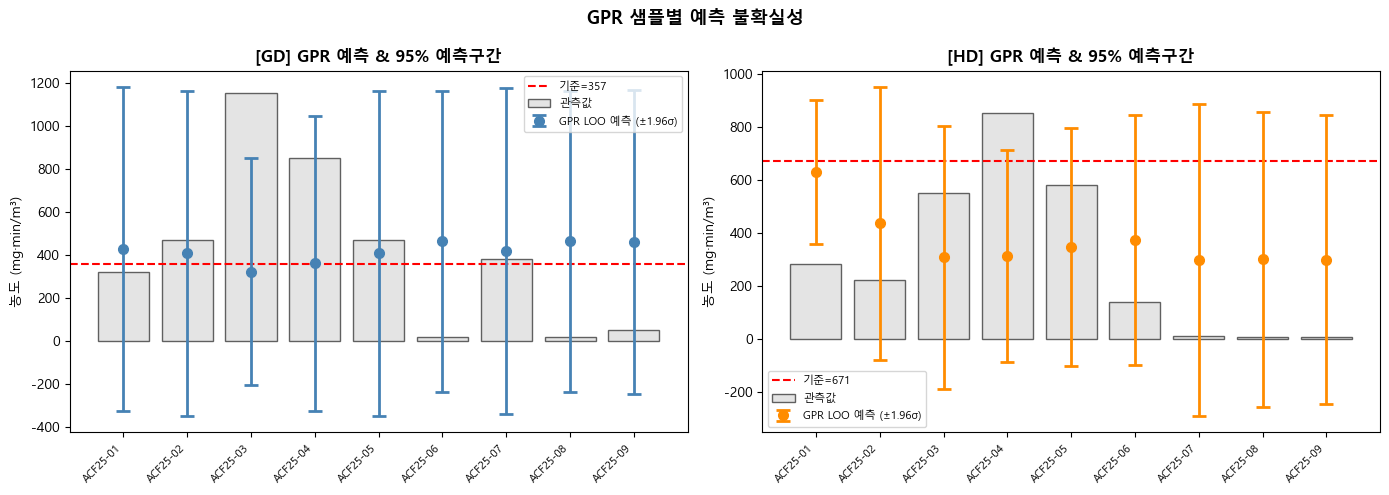

In [21]:
# GPR 샘플별 불확실성 바차트
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_pos = np.arange(n)

for ax, (target, y, base, color) in zip(axes, [
    ('GD', y_GD, GD_base, 'steelblue'),
    ('HD', y_HD, HD_base, 'darkorange'),
]):
    r = gpr_results[target]
    preds, stds = r['loo_pred'], r['loo_std']

    ax.bar(x_pos, y, color='lightgray', edgecolor='black', alpha=0.6, label='관측값')
    ax.errorbar(x_pos, preds, yerr=1.96*stds, fmt='o', color=color,
                markersize=7, linewidth=2, capsize=5, capthick=2,
                zorder=5, label='GPR LOO 예측 (±1.96σ)')
    ax.axhline(base, color='red', linestyle='--', linewidth=1.5, label=f'기준={base}')

    ax.set_xticks(x_pos)
    ax.set_xticklabels(samples, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('농도 (mg·min/m³)')
    ax.set_title(f'[{target}] GPR 예측 & 95% 예측구간', fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('GPR 샘플별 예측 불확실성', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

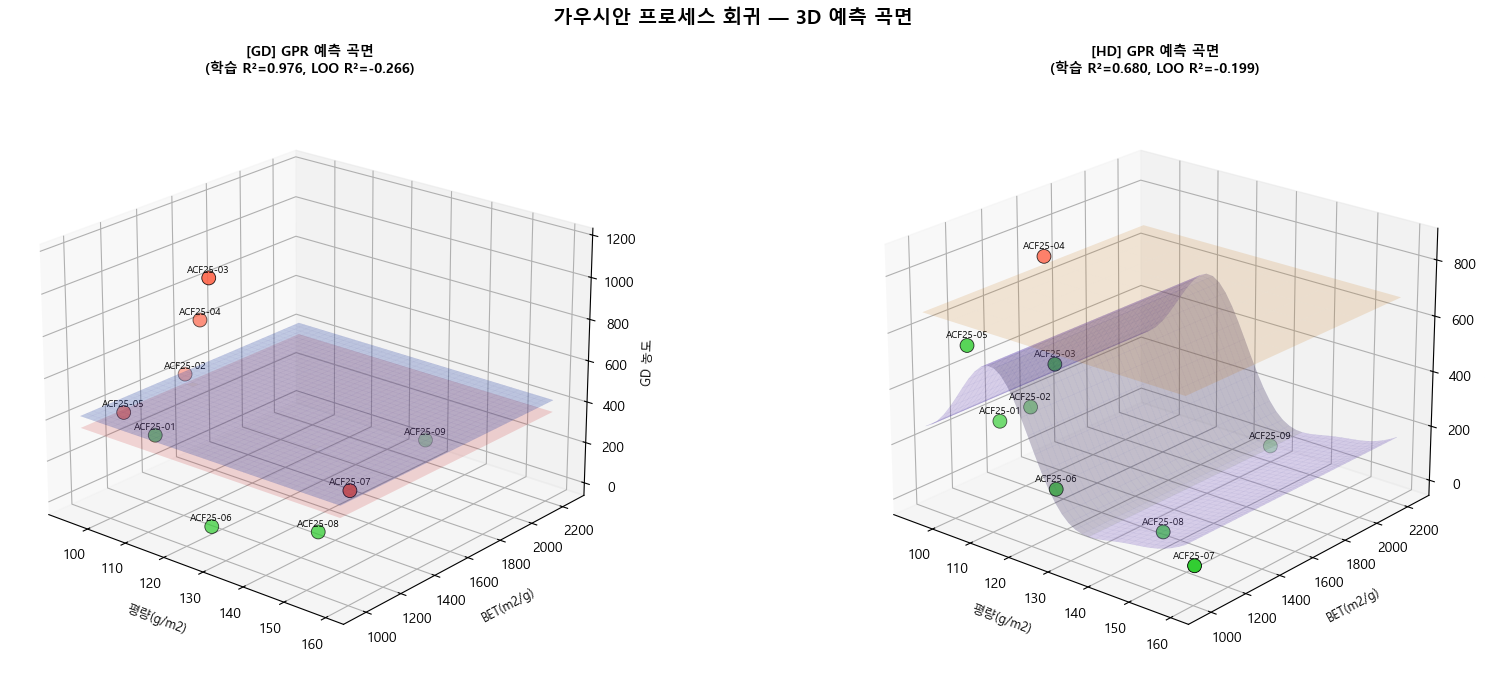

In [22]:
# GPR 3D 예측 곡면
grid_std = scaler_gpr.transform(grid_flat)

fig, axes_3d = plt.subplots(1, 2, figsize=(18, 7), subplot_kw={'projection': '3d'})

for ax, (target, y, base, surf_color, lim_color) in zip(axes_3d, [
    ('GD', y_GD, GD_base, 'royalblue',    'red'),
    ('HD', y_HD, HD_base, 'mediumpurple', 'darkorange'),
]):
    Zg_mean, _ = gpr_results[target]['model'].predict(grid_std, return_std=True)
    Zg_mean = Zg_mean.reshape(X1g.shape)

    ax.plot_surface(X1g, X2g, Zg_mean, alpha=0.28, color=surf_color, edgecolor='none')
    ax.plot_wireframe(X1g, X2g, Zg_mean, alpha=0.08, color='navy', linewidth=0.3)

    xx, yy = np.meshgrid(
        np.linspace(x1_arr.min()-5, x1_arr.max()+5, 10),
        np.linspace(x2_arr.min()-50, x2_arr.max()+50, 10))
    ax.plot_surface(xx, yy, np.full_like(xx, base), alpha=0.15, color=lim_color)

    pt_colors = ['limegreen' if v <= base else 'tomato' for v in y]
    ax.scatter(x1_arr, x2_arr, y, c=pt_colors, s=100,
               edgecolors='black', linewidths=0.6, depthshade=True, zorder=5)
    for xi, yi, zi, s in zip(x1_arr, x2_arr, y, samples):
        ax.text(xi, yi, zi + 25, s, fontsize=7, ha='center')

    ax.set_xlabel(label_w, fontsize=9, labelpad=8)
    ax.set_ylabel(label_b, fontsize=9, labelpad=8)
    ax.set_zlabel(f'{target} 농도', fontsize=9)
    ax.set_title(
        f'[{target}] GPR 예측 곡면\n(학습 R²={gpr_results[target]["in_r2"]:.3f}, LOO R²={gpr_results[target]["loo_r2"]:.3f})',
        fontsize=10, fontweight='bold')
    ax.view_init(elev=22, azim=-50)

plt.suptitle('가우시안 프로세스 회귀 — 3D 예측 곡면', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. 모형 성능 종합 비교

In [23]:
# 원본 OLS LOO 성능
X_ols = sm.add_constant(df[['weight', 'BET']].values)
m_ols_GD = sm.OLS(y_GD, X_ols).fit()
m_ols_HD = sm.OLS(y_HD, X_ols).fit()

ols_loo_GD = cross_val_predict(Ridge(alpha=1e-9), X_ols, y_GD, cv=loo)
ols_loo_HD = cross_val_predict(Ridge(alpha=1e-9), X_ols, y_HD, cv=loo)

def transform_loo_r2_rmse(transform_name, target, w, b, y_GD, y_HD):
    for name, yt_GD, yt_HD, x1_t, x2_t in transform_specs:
        if name != transform_name:
            continue
        yt = yt_GD if target == 'GD' else yt_HD
        y_orig = y_GD if target == 'GD' else y_HD
        X = np.column_stack([x1_t, x2_t])
        loo_p = cross_val_predict(Ridge(alpha=1e-9), X, yt, cv=loo)
        if 'log(y)' in name:
            loo_p_orig = np.exp(loo_p)
        elif 'sqrt(y)' in name:
            loo_p_orig = np.clip(loo_p, 0, None) ** 2
        else:
            loo_p_orig = loo_p
        return (round(r2_score(y_orig, loo_p_orig), 3),
                round(np.sqrt(np.mean((y_orig - loo_p_orig)**2)), 1))
    return np.nan, np.nan

tr_loo_r2_GD, tr_loo_rmse_GD = transform_loo_r2_rmse(best_name_GD, 'GD', w, b, y_GD, y_HD)
tr_loo_r2_HD, tr_loo_rmse_HD = transform_loo_r2_rmse(best_name_HD, 'HD', w, b, y_GD, y_HD)

summary = pd.DataFrame({
    '모형': ['원본 OLS', f'변환 OLS ({best_name_GD})', '다항 Ridge', 'GPR'],
    'GD 학습 R²': [
        round(m_ols_GD.rsquared, 3),
        round(models_by_name[best_name_GD][0].rsquared, 3),
        round(ridge_results['GD']['in_r2'], 3),
        round(gpr_results['GD']['in_r2'], 3),
    ],
    'GD LOO R²': [
        round(r2_score(y_GD, ols_loo_GD), 3),
        tr_loo_r2_GD,
        round(ridge_results['GD']['loo_r2'], 3),
        round(gpr_results['GD']['loo_r2'], 3),
    ],
    'GD LOO RMSE': [
        round(np.sqrt(np.mean((y_GD - ols_loo_GD)**2)), 1),
        tr_loo_rmse_GD,
        round(ridge_results['GD']['loo_rmse'], 1),
        round(gpr_results['GD']['loo_rmse'], 1),
    ],
    'HD 학습 R²': [
        round(m_ols_HD.rsquared, 3),
        round(models_by_name[best_name_HD][1].rsquared, 3),
        round(ridge_results['HD']['in_r2'], 3),
        round(gpr_results['HD']['in_r2'], 3),
    ],
    'HD LOO R²': [
        round(r2_score(y_HD, ols_loo_HD), 3),
        tr_loo_r2_HD,
        round(ridge_results['HD']['loo_r2'], 3),
        round(gpr_results['HD']['loo_r2'], 3),
    ],
    'HD LOO RMSE': [
        round(np.sqrt(np.mean((y_HD - ols_loo_HD)**2)), 1),
        tr_loo_rmse_HD,
        round(ridge_results['HD']['loo_rmse'], 1),
        round(gpr_results['HD']['loo_rmse'], 1),
    ],
})

print('=== 모형 성능 종합 비교 (LOO Cross-Validation) ===')
display(summary.style
        .background_gradient(subset=['GD 학습 R²','GD LOO R²','HD 학습 R²','HD LOO R²'], cmap='YlGn')
        .background_gradient(subset=['GD LOO RMSE','HD LOO RMSE'], cmap='YlOrRd'))

=== 모형 성능 종합 비교 (LOO Cross-Validation) ===


,모형,GD 학습 R²,GD LOO R²,GD LOO RMSE,HD 학습 R²,HD LOO R²,HD LOO RMSE
0,원본 OLS,0.182000,-0.385000,428.100000,0.454000,0.146000,263.800000
1,"변환 OLS (log(y), log(무게), log(BET))",0.243000,-0.412000,432.300000,0.831000,-0.886000,392.100000
2,다항 Ridge,0.242000,-20.070000,1669.800000,0.501000,-12.841000,1062.100000
3,GPR,0.976000,-0.266000,409.300000,0.680000,-0.199000,312.600000


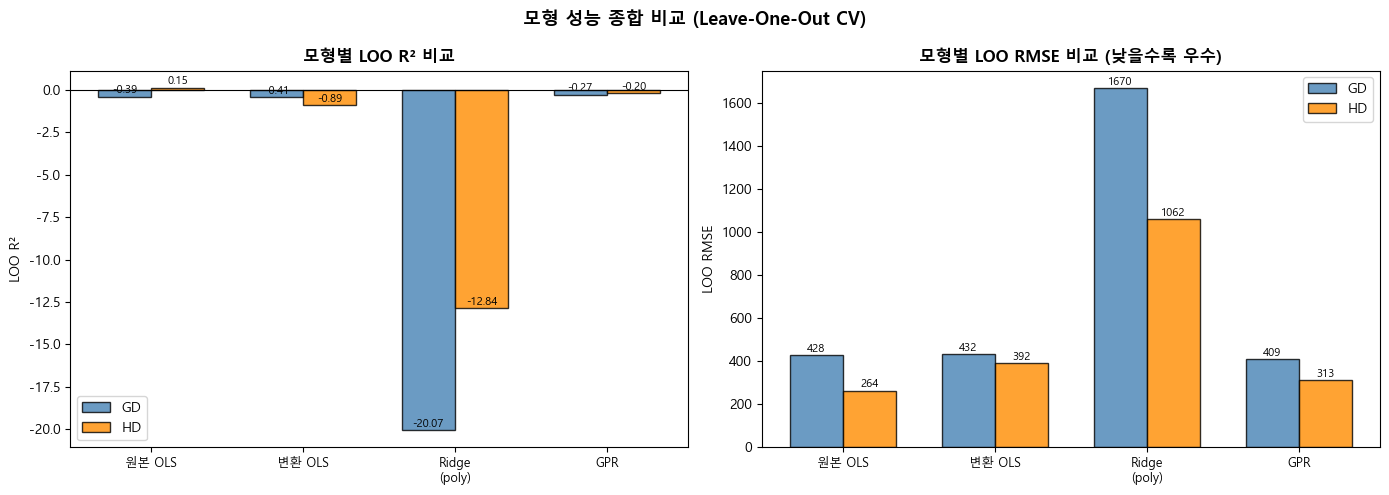

In [24]:
# 모형 비교 시각화
model_labels = ['원본 OLS', '변환 OLS', 'Ridge\n(poly)', 'GPR']

loo_r2_GD  = summary['GD LOO R²'].tolist()
loo_r2_HD  = summary['HD LOO R²'].tolist()
loo_rms_GD = summary['GD LOO RMSE'].tolist()
loo_rms_HD = summary['HD LOO RMSE'].tolist()

x_idx = np.arange(4)
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
b1 = ax.bar(x_idx - width/2, loo_r2_GD, width, label='GD', color='steelblue', edgecolor='black', alpha=0.8)
b2 = ax.bar(x_idx + width/2, loo_r2_HD, width, label='HD', color='darkorange', edgecolor='black', alpha=0.8)
ax.set_xticks(x_idx); ax.set_xticklabels(model_labels, fontsize=9)
ax.set_ylabel('LOO R²'); ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('모형별 LOO R² 비교', fontweight='bold')
ax.legend()
for b in list(b1) + list(b2):
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h + 0.01, f'{h:.2f}',
            ha='center', va='bottom', fontsize=8)

ax = axes[1]
b3 = ax.bar(x_idx - width/2, loo_rms_GD, width, label='GD', color='steelblue', edgecolor='black', alpha=0.8)
b4 = ax.bar(x_idx + width/2, loo_rms_HD, width, label='HD', color='darkorange', edgecolor='black', alpha=0.8)
ax.set_xticks(x_idx); ax.set_xticklabels(model_labels, fontsize=9)
ax.set_ylabel('LOO RMSE'); 
ax.set_title('모형별 LOO RMSE 비교 (낮을수록 우수)', fontweight='bold')
ax.legend()
for b in list(b3) + list(b4):
    h = b.get_height()
    ax.text(b.get_x() + b.get_width()/2, h + 2, f'{h:.0f}',
            ha='center', va='bottom', fontsize=8)

plt.suptitle('모형 성능 종합 비교 (Leave-One-Out CV)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()